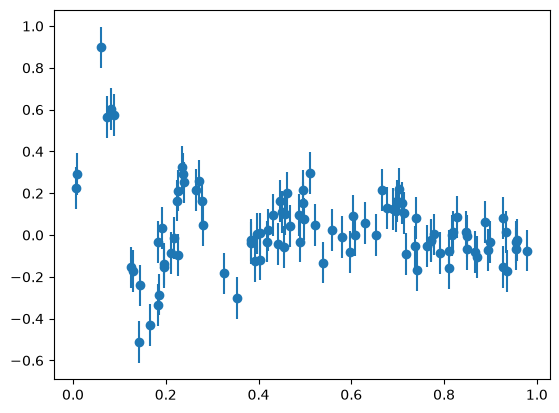

In [37]:
import matplotlib.pyplot as plt
import numpy as np

import jax
import jax.numpy as jnp
import jax.scipy.stats as stats
import jax.random as jr
import blackjax

num_data = 100;
noise_magnitude_on_each_point = 0.1;
k1, k2 = jr.split(jr.key(90))
x_obs = jr.uniform(k1, shape=(num_data,), minval=0.0, maxval=1.0)
y_obs_true = jnp.sin(30*x_obs) * jnp.exp(-5*x_obs)
y_obs_err = noise_magnitude_on_each_point * jnp.ones_like(y_obs_true)

y_obs = y_obs_true + y_obs_err * jr.normal(k2, shape=y_obs_true.shape)

plt.errorbar(x_obs, y_obs, yerr=y_obs_err, fmt='o', label='Observations')
plt.show()

In [38]:
rng_key = jr.key(0);
num_fixed_points = 50;
total_length = 1;


fixed_points_linspace = jnp.linspace(0, total_length, num_fixed_points);
differences = jnp.abs(x_obs[:, None] - fixed_points_linspace);
closest_indices = jnp.argmin(differences, axis=0);
y_values_at_fixed_points_linspace = y_obs[closest_indices];

def matern_32(r, variance=1.0, scale=0.2, jitter=1e-6):
    result = variance * (1 + jnp.sqrt(3)*r/scale)*jnp.exp(-1*jnp.sqrt(3)*r/scale);
    return jnp.where(r > 0, result, result * (1.0 + jitter))

def dist_function(i, j):
    return jnp.abs(i - j)*total_length/(num_fixed_points - 1);

shape = (num_fixed_points, num_fixed_points);
dist_matrix = jnp.fromfunction(dist_function, shape);
cov_matrix_matern_32 = matern_32(dist_matrix);

diagonal_values = jnp.ones(num_fixed_points)*noise_magnitude_on_each_point
diag_cov_data_matrix = jnp.diag(diagonal_values)

def logdensity_fn(guess_values):
    log_p_d_given_s = -0.5 * (guess_values - y_values_at_fixed_points_linspace).T @ jnp.linalg.inv(diag_cov_data_matrix) @ (guess_values - y_values_at_fixed_points_linspace)
    # add the log probabilities of P(d|s) and P(s)
    log_prior = -0.5*guess_values.T @ jnp.linalg.inv(cov_matrix_matern_32) @ guess_values
    return log_prior + log_p_d_given_s
   

In [39]:
inv_mass_matrix = cov_matrix_matern_32;
num_integration_steps = 60
step_size = 1e-3

hmc = blackjax.hmc(logdensity_fn, step_size, inv_mass_matrix, num_integration_steps)

initial_position = jnp.zeros(num_fixed_points)
initial_state = hmc.init(initial_position)
initial_state

HMCState(position=Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],      dtype=float32), logdensity=Array(-16.82406, dtype=float32), logdensity_grad=Array([ 2.2463465e+00,  2.9173360e+00,  8.9736500e+00,  8.9736500e+00,
        6.0351477e+00,  5.7256508e+00, -1.5506856e+00, -2.4113078e+00,
       -4.3218446e+00, -3.1826019e-01, -8.5948044e-01,  1.6510098e+00,
        2.5142586e+00,  2.1450634e+00,  4.9255803e-01, -1.8365123e+00,
       -1.8365123e+00, -3.0064502e+00, -3.0064502e+00, -2.2716329e-01,
        7.7893399e-02,  9.4509614e-01,  1.1021976e+00,  4.3580294e-01,
       -3.0984670e-01,  2.9823728e+00, -1.3156128e+00,  2.3848501e-01,
       -9.6314177e-02, -8.1660986e-01, -1.8277727e-02,  5.6120825e-01,
        4.9753301e-03,  1.2801522e+00,  1.1373049e+00,  1.0600553e+00,
       -5.4704672e-01, -5.3568280e-01,  

In [40]:
hmc_kernel = jax.jit(hmc.step)

def inference_loop(rng_key, kernel, initial_state, num_samples):
    @jax.jit
    def one_step(state, rng_key):
        state, _ = kernel(rng_key, state)
        return state, state

    keys = jax.random.split(rng_key, num_samples)
    _, states = jax.lax.scan(one_step, initial_state, keys)

    return states



rng_key, sample_key = jax.random.split(rng_key)
states = inference_loop(sample_key, hmc_kernel, initial_state, 10_000)

mcmc_samples = states.position

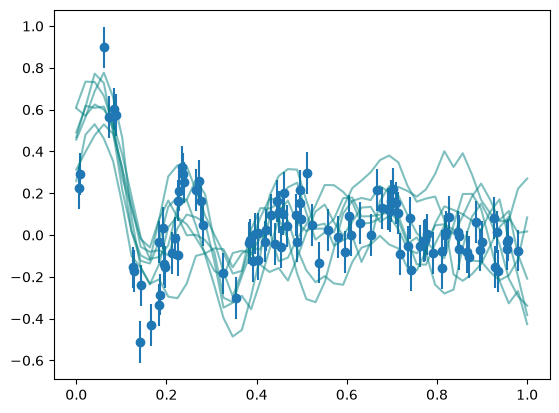

In [41]:
plt.errorbar(x_obs, y_obs, yerr=y_obs_err, fmt='o', label='Observations')
for i in range(0, 7):
    plt.plot(fixed_points_linspace, mcmc_samples[2500 + i*1000, :], label = "Posterior Sample", alpha = 0.5, color = 'teal');
plt.show();